# **クラウド技術の活用**

**クラウド上のストレージに接続してデータを処理する方法**

12.1 Amazon S3に接続してデータを処理

In [ ]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 3.7 MB/s eta 0:00:00


In [ ]:
import boto3
import pandas as pd
from io import StringIO

# AWSのアクセスキーとシークレットキーを設定
aws_access_key_id = 'YOUR_AWS_ACCESS_KEY_ID'
aws_secret_access_key = 'YOUR_AWS_SECRET_ACCESS_KEY'
bucket_name = 'YOUR_BUCKET_NAME'
file_key = 'path/to/your/file.csv'

# S3クライアントを作成
s3_client = boto3.client(
    's3',
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key
)

# S3からCSVファイルを読み込む
response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
csv_content = response['Body'].read().decode('utf-8')

# CSVコンテンツをDataFrameに変換
data = pd.read_csv(StringIO(csv_content))

# データの表示
print(data.head())

ClientError: An error occurred (InvalidAccessKeyId) when calling the GetObject operation: The AWS Access Key Id you provided does not exist in our records.

In [ ]:
# データの処理（例: 新しい列を追加）
data['new_column'] = data['existing_column'] * 2

# 変更したデータをS3にアップロード
csv_buffer = StringIO()
data.to_csv(csv_buffer, index=False)

s3_client.put_object(Bucket=bucket_name, Key='path/to/your/modified_file.csv', Body=csv_buffer.getvalue())

12.2 Google Driveに接続してデータを処理

In [ ]:
#必要なライブラリのインストール
!pip install google-auth google-auth-oauthlib google-auth-httplib2 google-api-python-client google-drive-api pydrive

  Preparing metadata (setup.py) ... done
  Created wheel for google-drive-api: filename=google_drive_api-0.0.4-py3-none-any.whl size=3043 sha256=83753fc4df3c3d4de4443c865ca1ad4953488d80c922c642d69e0f8bb0954fb8
  Stored in directory: /root/.cache/pip/wheels/5e/30/0d/929773ec655b7c42e02b91dd346196c64baf814b76e6406f77
Successfully built google-drive-api


In [ ]:
#データの読み込み
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
import pandas as pd
from io import BytesIO

# Google Drive認証
gauth = GoogleAuth()
gauth.LocalWebserverAuth()
drive = GoogleDrive(gauth)


# Google Drive上のファイルIDを指定してファイルを取得
file_id = 'YOUR_FILE_ID'
file = drive.CreateFile({'id': file_id})
file.GetContentFile('downloaded_file.csv')


# CSVファイルを読み込む
data = pd.read_csv('downloaded_file.csv')


# データの表示
print(data.head())

In [ ]:
# データの処理（例: 新しい列を追加）
data['new_column'] = data['existing_column'] * 2

# 変更したデータをGoogle Driveにアップロード
data.to_csv('modified_file.csv', index=False)
upload_file = drive.CreateFile({'title': 'modified_file.csv'})
upload_file.SetContentFile('modified_file.csv')
upload_file.Upload()

print(f'File uploaded with ID: {upload_file["id"]}')

***機械学習の実行 -教師あり学習-***

12.4 教師あり学習　ー　データの読み込みと前処理

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# データの読み込み
transaction_history = pd.read_csv('transaction_history.csv', dtype={'customer_id': str})

# purchase_dateを日付型に変換（不正な日付はNaTに変換）
transaction_history['purchase_date'] = pd.to_datetime(
    transaction_history['purchase_date'],
    format='mixed',
    errors='coerce'
).dt.date

# データの確認
print(transaction_history.head())

  customer_id product_id purchase_date  purchase_amount  redeem_coupon  \
0    00023085   G03257PD    2020-03-13             7200           True   
1    00015469   CKZF21ZC    2023-03-29            15400          False   
2    00015482   7NSE0G0R    2023-12-26            15400          False   
3    00017107   WVCPYZBH    2021-02-19            17100          False   
4    00024156   OELTJ7E2    2020-10-08            24100           True   

   final_settlement_amount payment_method  purchase_channel  
0                   6200.0             現金                 2  
1                      NaN            カード                 2  
2                      NaN             現金                 1  
3                      NaN            カード                 2  
4                  23100.0            カード                 1  


In [ ]:
# データの分割
train_data = transaction_history[(transaction_history['purchase_date'] >= '2018-01-01') &
                                 (transaction_history['purchase_date'] <= '2021-12-31')]
test_data = transaction_history[transaction_history['purchase_date'] >= '2022-01-01']

# Customer_IDごとの累計購入金額の合計を算出
train_data_agg = train_data.groupby('customer_id')['purchase_amount'].sum().reset_index()
test_data_agg = test_data.groupby('customer_id')['purchase_amount'].sum().reset_index()

# カラム名の変更
train_data_agg.columns = ['customer_id', 'total_purchase_amount']
test_data_agg.columns = ['customer_id', 'total_purchase_amount']

print(train_data_agg.head())
print(test_data_agg.head())

  customer_id  total_purchase_amount
0    00010000                   9300
1    00010001                   8300
2    00010002                 164700
3    00010003                  46000
4    00010011                  72100
  customer_id  total_purchase_amount
0    00010004                  69300
1    00010005                 104100
2    00010006                   8700
3    00010007                 237100
4    00010008                  96600


12.5 教師あり学習　ー　モデルの構築

In [ ]:
# 特徴量とターゲットの設定
X_train = train_data_agg.drop(columns=['total_purchase_amount'])
y_train = train_data_agg['total_purchase_amount']
X_test = test_data_agg.drop(columns=['total_purchase_amount'])
y_test = test_data_agg['total_purchase_amount']

# モデルの定義
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# モデルの学習
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# 予測
y_pred = model.predict(X_test)


# モデル評価
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 124484.4195326758


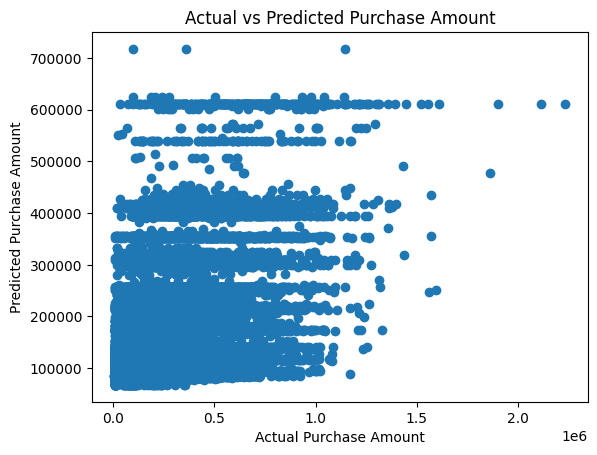

In [ ]:
# 結果の可視化
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Purchase Amount')
plt.ylabel('Predicted Purchase Amount')
plt.title('Actual vs Predicted Purchase Amount')
plt.show()

**機械学習の実行 -教師なし学習-**

12.6 教師なし学習ーデータの抽出

In [ ]:
import pandas as pd

# データの読み込み
transaction_history = pd.read_csv('transaction_history.csv', dtype={'customer_id': str})

# データの確認
print(transaction_history.head())

  customer_id product_id purchase_date  purchase_amount  redeem_coupon  \
0    00023085   G03257PD     2020/3/13             7200           True   
1    00015469   CKZF21ZC     2023/3/29            15400          False   
2    00015482   7NSE0G0R    2023/12/26            15400          False   
3    00017107   WVCPYZBH     2021/2/19            17100          False   
4    00024156   OELTJ7E2     2020/10/8            24100           True   

   final_settlement_amount payment_method  purchase_channel  
0                   6200.0             現金                 2  
1                      NaN            カード                 2  
2                      NaN             現金                 1  
3                      NaN            カード                 2  
4                  23100.0            カード                 1  


In [ ]:
# Customer_IDごとに購入したProduct_IDを抽出
customer_products = transaction_history.groupby('customer_id')['product_id'].apply(list).reset_index()
print(customer_products.head())

  customer_id  product_id
0    00010000  [AMHRGDP0]
1    00010001  [4ZIQTGYU]
2    00010002  [BV0C09UO]
3    00010003  [9HJSVDFB]
4    00010004  [AVLRU30G]


12.6 教師なし学習ー都市名の紐づけ

In [ ]:
# product_masterの読み込み
product_master = pd.read_csv('product_master.csv')

# データの確認
print(product_master.head())

  product_id            product_name  product_type     price departure_city  \
0   8RBQ8O3I   リラックスできるニューヨーク 6日間ツアー             3  294000.0             福岡   
1   ZFQK59UL          ドキドキの香港 5日間ツアー             3   144600円             京都   
2   5YH8O89R  ジャパンウィング航空 東京 → 高松 航空券             2   13600.0             東京   
3   MQTY8P6S           贅沢なドバイ 6日間ツアー             3  207000.0             東京   
4   1FKCUCHP           贅沢なドバイ 8日間ツアー             3  235000.0             京都   

  destination_city register_date  \
0           ニューヨーク     2023/8/28   
1               香港    2023/12/24   
2               高松      2024/9/5   
3              ドバイ    2024/10/29   
4              ドバイ     2023/5/13   

                                        description  
0   ニューヨークの魅力を存分に楽しめる6日間のツアー。リラックスできる体験を満喫し、心に残る旅を。  
1          香港の魅力を存分に楽しめる5日間のツアー。ドキドキな体験を満喫し、心に残る旅を。  
2  東京から高松へ、ジャパンウィング航空で快適な国内旅行を。お得な航空券で気軽に旅に出かけましょう。  
3           ドバイの魅力を存分に楽しめる6日間のツアー。贅沢な体験を満喫し、心に残る旅を。  
4           ドバイの魅力を存分に楽しめる8日間のツアー。贅沢な体

<ipython-input-17-c74d2de1e382>:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  product_master = pd.read_csv('product_master.csv')


12.7 教師なし学習ー都市名の紐づけ

In [ ]:
# product_idと渡航先の都市名をマージ
transaction_history = pd.merge(transaction_history, product_master[['product_id', 'destination_city']], on='product_id', how='left')

# customer_idごとに渡航先の都市名を抽出
customer_destinations = transaction_history.groupby('customer_id')['destination_city'].apply(list).reset_index()
print(customer_destinations.head())

  customer_id destination_city
0    00010000             [パリ]
1    00010001             [松山]
2    00010002         [シンガポール]
3    00010003           [シドニー]
4    00010004            [ソウル]


12.8 教師なし学習ークロス集計表に変換

In [ ]:
# 渡航先の都市名をカウント
customer_destinations_exploded = customer_destinations.explode('destination_city')
customer_destination_counts = customer_destinations_exploded.groupby(['customer_id', 'destination_city']).size().unstack(fill_value=0)
print(customer_destination_counts.head())

destination_city  シドニー  シンガポール  ソウル  ドバイ  ニューヨーク  バンコク  パリ  ロンドン  ローマ  函館  \
customer_id                                                                 
00010000             0       0    0    0       0     0   1     0    0   0   
00010001             0       0    0    0       0     0   0     0    0   0   
00010002             0       1    0    0       0     0   0     0    0   0   
00010003             1       0    0    0       0     0   0     0    0   0   
00010004             0       0    1    0       0     0   0     0    0   0   

destination_city  ...  旭川  松山  熊本  秋田  那覇  長崎  青森  静岡  香港  高松  
customer_id       ...                                          
00010000          ...   0   0   0   0   0   0   0   0   0   0  
00010001          ...   0   1   0   0   0   0   0   0   0   0  
00010002          ...   0   0   0   0   0   0   0   0   0   0  
00010003          ...   0   0   0   0   0   0   0   0   0   0  
00010004          ...   0   0   0   0   0   0   0   0   0   0  

[5 rows x 2

12.9 教師なし学習ーK-meansクラスタリングの実行

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-meansクラスタリングの実行
kmeans = KMeans(n_clusters=5, random_state=42)
customer_clusters = kmeans.fit_predict(customer_destination_counts)

# クラスタリング結果の追加
customer_destination_counts['Cluster'] = customer_clusters
print(customer_destination_counts.head())

destination_city  シドニー  シンガポール  ソウル  ドバイ  ニューヨーク  バンコク  パリ  ロンドン  ローマ  函館  \
customer_id                                                                 
00010000             0       0    0    0       0     0   1     0    0   0   
00010001             0       0    0    0       0     0   0     0    0   0   
00010002             0       1    0    0       0     0   0     0    0   0   
00010003             1       0    0    0       0     0   0     0    0   0   
00010004             0       0    1    0       0     0   0     0    0   0   

destination_city  ...  松山  熊本  秋田  那覇  長崎  青森  静岡  香港  高松  Cluster  
customer_id       ...                                               
00010000          ...   0   0   0   0   0   0   0   0   0        2  
00010001          ...   1   0   0   0   0   0   0   0   0        0  
00010002          ...   0   0   0   0   0   0   0   0   0        1  
00010003          ...   0   0   0   0   0   0   0   0   0        0  
00010004          ...   0   0   0   0   0   0 

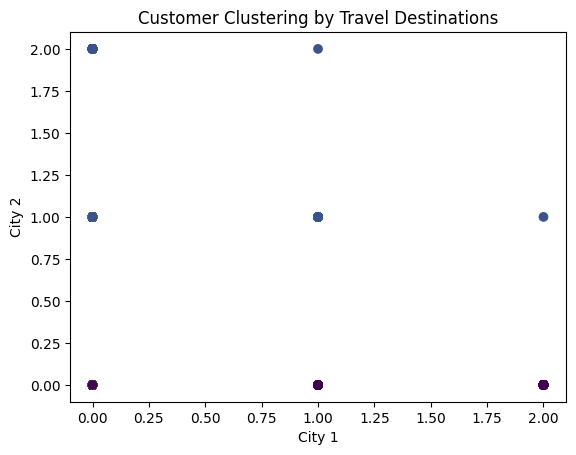

In [ ]:
# クラスタリング結果の可視化
plt.scatter(customer_destination_counts.iloc[:, 0], customer_destination_counts.iloc[:, 1], c=customer_clusters, cmap='viridis')
plt.xlabel('City 1')
plt.ylabel('City 2')
plt.title('Customer Clustering by Travel Destinations')
plt.show()

12.10 教師なし学習ー顧客ごとのMonetary_Rankの読み込み

In [ ]:
# df_Rankの読み込み
df_Rank = pd.read_csv('df_M_Rank.csv', dtype={'customer_id': str})

# データの確認
print(df_Rank.head())

  customer_id  purchase_amount     M_Rank
0    00010000        5153500.0  Very High
1    00010001        2944500.0        Low
2    00010002        2167400.0        Low
3    00010003        3515700.0     Medium
4    00010004        3385400.0     Medium


12.11 教師なし学習ー顧客のクラスタNoごとにMonetary_Rankを紐づけ

In [ ]:
# クロス集計表とクラスタラベルを表示
print(customer_destination_counts.head())

# クロス集計表にMonetary_Rankを追加（結合）
customer_destination_counts = customer_destination_counts.reset_index()
df_Rank = df_Rank[['customer_id', 'M_Rank']]
merged_data = pd.merge(customer_destination_counts, df_Rank, on='customer_id', how='left')

# クラスタごとのMonetary_Rankの確認
print(merged_data.head())

destination_city customer_id  シドニー  シンガポール  ソウル  ドバイ  ニューヨーク  バンコク  パリ  ロンドン  \
0                   00010000     0       0    0    0       0     0   1     0   
1                   00010001     0       0    0    0       0     0   0     0   
2                   00010002     0       1    0    0       0     0   0     0   
3                   00010003     1       0    0    0       0     0   0     0   
4                   00010004     0       0    1    0       0     0   0     0   

destination_city  ローマ  ...  松山  熊本  秋田  那覇  長崎  青森  静岡  香港  高松  Cluster  
0                   0  ...   0   0   0   0   0   0   0   0   0        2  
1                   0  ...   1   0   0   0   0   0   0   0   0        0  
2                   0  ...   0   0   0   0   0   0   0   0   0        1  
3                   0  ...   0   0   0   0   0   0   0   0   0        0  
4                   0  ...   0   0   0   0   0   0   0   0   0        0  

[5 rows x 25 columns]
   index customer_id  シドニー  シンガポール  ソウル  ドバイ  ニューヨーク

In [ ]:
# クラスタとM_rankのクロス集計
cross_tab = pd.crosstab(merged_data['Cluster'], merged_data['M_Rank'])
cross_tab

M_Rank,High,Low,Medium,Very High,Very Low
Cluster,,,,,
0,1777,2644,4353,312,274
1,355,572,933,69,39
2,199,273,490,41,26
3,179,304,452,37,28
4,210,301,493,29,29


12.12 生成AIを用いた前処理の効率化

In [ ]:
import openai
# OpenAI APIキーの設定
openai.api_key = 'YOUR_API_KEY'

In [ ]:
def clean_text(text):
    # テキストのクレンジング
    response = openai.Completion.create(
        engine="davinci-codex",
        prompt=f"Clean the following text for noise and unnecessary characters:\n\n{text}",
        max_tokens=500
    )
    return response.choices[0].text.strip()


def tokenize_text(text):
    # テキストのトークナイゼーション
    response = openai.Completion.create(
        engine="davinci-codex",
        prompt=f"Tokenize the following text into individual words:\n\n{text}",
        max_tokens=500
    )
    return response.choices[0].text.strip().split()


# サンプルテキスト
sample_text = "This is an example text with some noise! #$%^&*()"


# テキストのクレンジング
cleaned_text = clean_text(sample_text)
print("Cleaned Text:", cleaned_text)


# トークナイゼーション
tokens = tokenize_text(cleaned_text)
print("Tokens:", tokens)
